In [ ]:
### 003번 파일에서는 단순선형회귀 였어요
## 쉽게 말하면 피처가 1개.. y = ax + b
## 즉 x가 공부시간... 그런데 공부시간만 성적을 좌우 할 수 없다.
## 피처가 여러개 있어야 더 정확하지..
## 그래서 공식이 y = ax1 + bx2 + d
## 기울기가 2개, 피처가 2개.. 이래야 하지 더 정확하지..
## 총 피처가 2개, 결과가 1개.. 3차원이네요.. 그래프로 그리기 힘들겠다.

## 이번 장에서는 피처를 2개만 해 봅시다. 
## 다중선형회귀.. 회귀 라는 단어가 있기 때문에 연속된 값을 예측..
##              다중 이라는 단어는 피처가 여러개..
##             공식 : y = ax1 + bx2 + d

In [3]:
import pandas as pd
df = pd.DataFrame({
    "study_hours": [1,2,3,4,5,6,7,8,9,10,
                    1,2,3,4,5,6,7,8,9,10],
    "score": [60,55,60,65,70,75,80,82,85,88,
              52,58,62,67,72,76,81,83,86,90]
})
# 피처 1개더 추가
df['focus']=[1,1,2,2,3,3,4,4,5,5,1,1,2,2,3,3,4,4,5,5]

In [2]:
df

,study_hours,score,focus
0,1,60,1
1,2,55,1
2,3,60,2
3,4,65,2
4,5,70,3
5,6,75,3
6,7,80,4
7,8,82,4
8,9,85,5
9,10,88,5


In [ ]:
# 실무에서는 모델을 개발 할 때 다음과 같은 단계를 거친다.
# 1. 데이터 로딩
# 2. 데이터 전처리 - 결측치, 이상치, 형변환(인공지능 모델은 문자인식 못함)
# 3. 시각화 - 피처들의 관계나, 데이터 분포등 참고한다. 
# 4. 데이터셋나누기 - 중요..  
#    4-1.학습데이터와 정답데이터   
#    4-2.<나중에> 학습한 데이터가 잘 학습되었는지 확인요 - 오늘 안함.
#    4-3.학습이 끝난후 잘 학습에 되었는지 테스트 하기 위한 데이터
# 5. 모델을 만들고, 학습을 시킨다
# 6. 평가합니다. - 모델이 학습이 끝난 후 테스트 데이터로 예측값을 예측
#                한 값과 
#                테스트 데이터의 정답과 비교해서 평가 한다.

In [ ]:
# 1. 데이터 로딩


In [ ]:
#2. 데이터 전처리는 결측치,, 생략

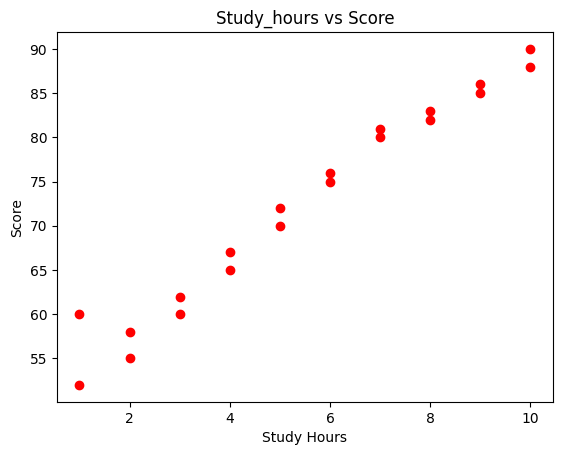

In [5]:
#3. 시각화  - 참고.. 아하. 공부 시간은 성적에 비례하는 구나..
# 이렇게 모델만드면 공부시간과 비례하는 값을 예측하겠구나.

import matplotlib.pyplot as plt

#산점도 그래프
plt.scatter(df['study_hours'], df['score'], color='red')
plt.title('Study_hours vs Score')
plt.xlabel('Study Hours')
plt.ylabel('Score')
plt.show()

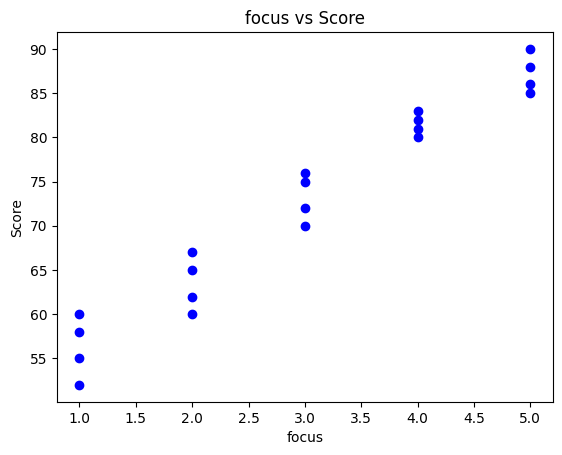

In [ ]:
#3. 시각화  - 참고.. 아하. 집중하는 시간은 성적에 비례하는 구나..
# 이렇게 모델만드면 공부시간과 비례하는 값을 예측하겠구나.

import matplotlib.pyplot as plt

#산점도 그래프
plt.scatter(df['focus'], df['score'], color='blue')
plt.title('focus vs Score')
plt.xlabel('focus')
plt.ylabel('Score')
plt.show()

In [7]:
#4. 데이터셋나누기 - 중요.
from sklearn.model_selection import train_test_split
X = df[['study_hours','focus']]  #행의 갯수 샘플수, 열의 컬럼 :피처수
y=df['score']

# 데이터셋 나누는 전략 **
# X_train은 학습할 때 학습용 문제 데이터,
# y_train은 학습할 때 학습용 문제에 대응되는 정답.. 
# 이렇게 지도학습을 합니다. 그래서 기울기랑 절편이 만들어 진다.
# 모델이 학습을 완료하면.. 이 모델어 똑똑한가 확인한다.
# 이때 X_test값으로 예측하도록 합니다. 그럼 값이 나오겠죠
# 그 값과 y_test값과 비교해서 성능을 측정합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   #0.2는 X,y에서 20프로만 테스트용으로 잘라
    random_state=42 # 데이터가 특정 영역에 집중되지않도록 썪어라
    # 문제를 램던하게 주겠다. 과적합 방지..
    # 과적합은 비슷한 문제만 보고 외워 버려서.. 학습의 결과는 좋으나
    # 새로운 문제에 대한 답은 .. 정답과 아주 큰 거리감이 있다.
)

In [ ]:
# 5. 모델을 만들고, 학습을 시킨다
# 저희가 개발하고자 하는 모델은 선형회귀입니다.. 
from sklearn.linear_model import LinearRegression
model = LinearRegression()  # y= ax + b
model.fit(X_train, y_train)

print("계수(기울기)",model.coef_)
print("절편 intercept", model.intercept_)

# y = ax1 + bx2 + c
# a의 기울기는 3.6, x1의 피처가 3.6 정도의 + 효과가 있다.
# b의 기울기는  0.8, x2의 피처가 0.8정도의 + 효과
# 여기서 x1은 공부시간 ,  x2는 집중시간..

계수(기울기) [3.64718163 0.86012526]
절편 intercept 49.37160751565762


In [9]:
# 6. 평가
# 평가는 모델이 학습이 완료 되어서 공식이 나왔다.
# 이 공식에  X_test값으로 학습을 시켜 예측값을 만든다
# 예측한값과 y_test값의 차이를 분석한다.

#예측값 만들기
y_pred = model.predict(X_test)
print(y_pred)
print(y_test)

#평가하자.
# 중요, 개중요,,, 
# 회귀에서는 평가를 할때  MSE평가랑 RMSE평가 R2 평가
# 평가함수를 import
from sklearn.metrics import mean_squared_error, r2_score

#mse - 예측값과 실제값 차이를 제곱해서 평균낸 값
# 제곱을 하는 이유는 작은 값에 큰값 빼면 마이너스.
# 차이라는 것은 마이너스의 의미가 아니라서 마이너스 없애려고 제곱 
mse=mean_squared_error(y_test, y_pred)
print(mse)


# r2 계수는 얼마 정확한지를 판단합니다. 
# 평균을 내서 예측하는 것이랑, 모델이 예측하는 것으로 판단..
# r2 계수는 
# 1.0 완벽(의심)
# 0.8정도면 좋다.. 
# 0 이면 평균으로 예측하는것과 동일
# < 0 평균으로 찍는것보다 못하다..
r2=r2_score(y_test, y_pred)
print(r2)

# RMSE평가
import numpy as np
rmse = np.sqrt(mse)
print(rmse)  # 평균 3.58 정도의 예측값이 오류가 날 수 있다.

# r2가 0.9이상  rmse가 3.85정도의 차이가 날 수 있다.
# 즉, 준수한 성능의 모델이 개발되었다..



[53.87891441 81.98956159 73.83507307 57.52609603]
0     60
17    83
15    76
1     55
Name: score, dtype: int64
12.38918610884714
0.9048814886076995
3.5198275680560176


In [10]:
## 새로운 값 예측
new_X =[[4,3],
        [20,1],
        [5,1]]

new_y = model.predict(new_X)
print(new_y)

## new_y 결과에서 100을 넘으면 100으로 수정해 주는 작업 필요

[ 66.54070981 123.17536534  68.46764092]


d:\Data\260126Tr\AI\Linear\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# 오전에는 선형회귀를 공부했다.
# 지도학습 (학습데이터셋 (문제와 답을 제공))
# 선형회귀 중 단순선형회귀랑 다중선형회귀를 공부 함.
# 공식을 같이 이해.
# 회귀와 분류 차이점 이해..
# 개발하는 순서는 데이터로딩 > 전처리 > 시각화해서 참고
#         > 데이터셋 분할 > 모델생성및 학습 > 평가 > 새로운값 예측
# 회귀 모들 평가는 MSE, RMSE, r2(알투)계수로 확인..
# 데이터셋 나누는 전략 이해.

# 인공지능의 뿌리가 y = aX + b 공식이라도 봐도 무방.
# 즉, 그만큼 중요한 공식이라서 이해하면 좋다.